In [8]:
import os
import cv2
import numpy as np


os.makedirs('data/cats', exist_ok=True)
os.makedirs('data/dogs', exist_ok=True)


for i in range(20):
    img = np.zeros((64, 64, 3), dtype=np.uint8) + 30  
    center = (32 + np.random.randint(-5, 5), 32 + np.random.randint(-5, 5))
    radius = np.random.randint(18, 24)
    cv2.circle(img, center, radius, (200, 200, 200), -1)  
    cv2.circle(img, (center[0]-8, center[1]-5), 3, (0, 0, 0), -1)  
    cv2.circle(img, (center[0]+8, center[1]-5), 3, (0, 0, 0), -1)  
    cv2.imwrite(f"data/cats/cat_{i}.jpg", img)


for i in range(20):
    img = np.zeros((64, 64, 3), dtype=np.uint8) + 200  
    pt1 = (12 + np.random.randint(-4, 4), 12 + np.random.randint(-4, 4))
    pt2 = (52 + np.random.randint(-4, 4), 52 + np.random.randint(-4, 4))
    cv2.rectangle(img, pt1, pt2, (50, 50, 50), -1)  
    cv2.imwrite(f"data/dogs/dog_{i}.jpg", img)

print("Generated structured shape images for Cats and Dogs!")

Generated structured shape images for Cats and Dogs!


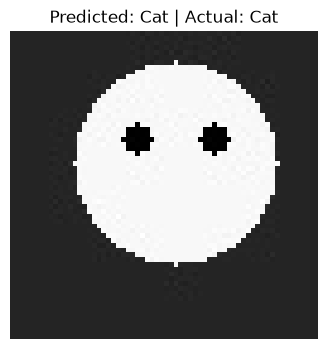

In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


IMG_SIZE = 64
data, labels = [], []
categories = {'cats': 0, 'dogs': 1}

for category, label in categories.items():
    folder_path = os.path.join('data', category)
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append(img.flatten())
            labels.append(label)

X = np.array(data) / 255.0
y = np.array(labels)


np.random.seed(42)
indices = np.arange(len(X))
np.random.shuffle(indices)

split_idx = int(len(X) * 0.8)
train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


cat_mean = np.mean(X_train[y_train == 0], axis=0)
dog_mean = np.mean(X_train[y_train == 1], axis=0)

y_pred = np.array([
    0 if np.linalg.norm(sample - cat_mean) < np.linalg.norm(sample - dog_mean) else 1 
    for sample in X_test
])


sample_img = X_test[0].reshape(IMG_SIZE, IMG_SIZE)
pred_label = "Dog" if y_pred[0] == 1 else "Cat"
actual_label = "Dog" if y_test[0] == 1 else "Cat"

plt.figure(figsize=(4, 4))
plt.imshow(sample_img, cmap='gray')
plt.title(f"Predicted: {pred_label} | Actual: {actual_label}")
plt.axis('off')
plt.show()

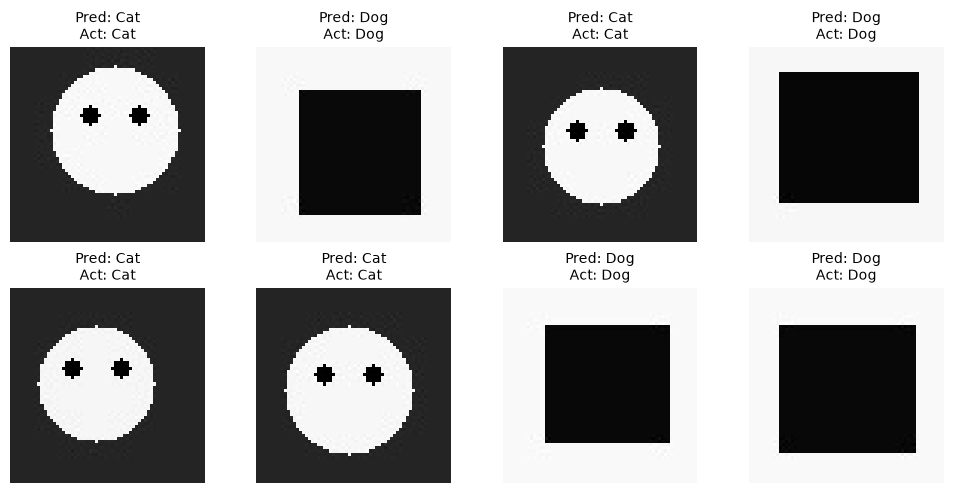

In [10]:
plt.figure(figsize=(10, 5))


for i in range(min(8, len(X_test))):
    plt.subplot(2, 4, i + 1)
    img = X_test[i].reshape(IMG_SIZE, IMG_SIZE)
    pred = "Dog" if y_pred[i] == 1 else "Cat"
    actual = "Dog" if y_test[i] == 1 else "Cat"
    
    plt.imshow(img, cmap='gray')
    plt.title(f"Pred: {pred}\nAct: {actual}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()